In [396]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [397]:
# Load a specific output folder (recommended) OR auto-pick newest
from pathlib import Path
import time

# Option A (recommended): point directly to the newest run folder
OUTPUT_DIR = Path(r"C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-03-06_21-36-20")

# Basic guardrails
if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"OUTPUT_DIR does not exist: {OUTPUT_DIR}")

q_path = OUTPUT_DIR / "q_save.npy"
u_path = OUTPUT_DIR / "u_save.npy"
X_path = OUTPUT_DIR / "X_save.npy"
for p in [q_path, u_path, X_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Using output:", OUTPUT_DIR)
print("q_save.npy mtime:", time.ctime(q_path.stat().st_mtime))
print("u_save.npy mtime:", time.ctime(u_path.stat().st_mtime))
print("X_save.npy mtime:", time.ctime(X_path.stat().st_mtime))

q = np.load(q_path)
u = np.load(u_path)
X = np.load(X_path)

# Load pendulum data if available
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    phi_dot = np.load(OUTPUT_DIR / "phi_dot_save.npy")
    phi_ddot = np.load(OUTPUT_DIR / "phi_ddot_save.npy")
    has_pendulum_data = True
    print("Pendulum data loaded successfully")
except FileNotFoundError:
    has_pendulum_data = False
    print("No pendulum data found (older simulation format)")

params_path = OUTPUT_DIR / "params.json"
params = json.loads(params_path.read_text(encoding="utf-8")) if params_path.exists() else {}

# ── Load stair geometry ─────────────────────────────────────────────
# The simulation saves stair_segments.npy as an (N, 4) array of
# [x1, y1, x2, y2] line segments.  Fall back to flat ground if missing.
_seg_path = OUTPUT_DIR / "stair_segments.npy"
if _seg_path.exists():
    stair_segments = np.load(_seg_path)          # shape (N, 4)
    print(f"Loaded {len(stair_segments)} stair segments from stair_segments.npy")
else:
    stair_segments = np.array([[-1e6, 0.0, 1e6, 0.0]])  # flat ground
    print("No stair_segments.npy found — defaulting to flat ground")

n_stairs     = params.get("n_stairs", 0)
stair_width  = params.get("stair_width", 0)
stair_height = params.get("stair_height", 0)
stair_x_start = params.get("stair_x_start", 0)
print(f"Stair params: n_stairs={n_stairs}, width={stair_width}, height={stair_height}, x_start={stair_x_start}")

# Helper: closest point on segment list (mirrors simulation code)
def closest_point_on_segments(px, py, segments):
    """Return (cx, cy, dist, nx, ny) for the closest point on the polyline."""
    min_d2 = np.inf
    best_cx, best_cy = 0.0, 0.0
    for seg in segments:
        x1, y1, x2, y2 = seg
        dx, dy = x2 - x1, y2 - y1
        L2 = dx*dx + dy*dy
        if L2 < 1e-30:
            cx, cy = x1, y1
        else:
            t = max(0.0, min(1.0, ((px - x1)*dx + (py - y1)*dy) / L2))
            cx = x1 + t*dx
            cy = y1 + t*dy
        d2 = (px - cx)**2 + (py - cy)**2
        if d2 < min_d2:
            min_d2 = d2
            best_cx, best_cy = cx, cy
    dist = np.sqrt(min_d2)
    if dist < 1e-15:
        nx, ny = 0.0, 1.0
    else:
        nx = (px - best_cx) / dist
        ny = (py - best_cy) / dist
    return best_cx, best_cy, dist, nx, ny

# Build stair drawing polyline for visualization (from segments array)
def build_stair_polyline_from_segments(segments, x_pad_left=2.0, x_pad_right=2.0):
    """Return (xs, ys) arrays tracing the visible stair surface for plotting.
    Clips the FAR segments to a sensible range and draws every segment vertex."""
    xs, ys = [], []
    for seg in segments:
        x1, y1, x2, y2 = seg
        # Clip extreme extents used for the solver's "infinite" ground/tread
        x1c = np.clip(x1, -x_pad_left, x_pad_right)
        x2c = np.clip(x2, -x_pad_left, x_pad_right)
        # Interpolate y at clipped x if horizontal (avoid adding degenerate points)
        if abs(x2 - x1) > 1e-12:
            frac1 = (x1c - x1) / (x2 - x1)
            frac2 = (x2c - x1) / (x2 - x1)
            y1c = y1 + frac1 * (y2 - y1)
            y2c = y1 + frac2 * (y2 - y1)
        else:
            y1c, y2c = y1, y2
        xs.extend([x1c, x2c])
        ys.extend([y1c, y2c])
    return np.array(xs), np.array(ys)

print("q0 from file =", q[:, 0])
print("u0 from file =", u[:, 0])
if "q0" in params:
    print("params.json q0 =", params["q0"])
if "u0" in params:
    print("params.json u0 =", params["u0"])
for k in ["x0_input", "y0_input", "theta0_input", "omega0_input", "l_pendulum", "m_pendulum", "m_hoop"]:
    if k in params:
        print(f"params.json {k} =", params[k])

print("q shape:", q.shape)
print("u shape:", u.shape)
print("X shape:", X.shape)
if has_pendulum_data:
    print("phi shape:", phi.shape)

# Show a couple later states to confirm runs differ even when q0 matches
print("q[:,1] =", q[:, 1])
if q.shape[1] > 10:
    print("q[:,10] =", q[:, 10])

Using output: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-03-06_21-36-20
q_save.npy mtime: Fri Mar  6 21:37:11 2026
u_save.npy mtime: Fri Mar  6 21:37:11 2026
X_save.npy mtime: Fri Mar  6 21:37:11 2026
Pendulum data loaded successfully
Loaded 7 stair segments from stair_segments.npy
Stair params: n_stairs=3, width=0.5, height=0.08, x_start=0.5
q0 from file = [0.2  0.18 0.   0.  ]
u0 from file = [  0.   0.   0. -20.]
params.json q0 = [0.2, 0.18, 0.0]
params.json u0 = [0.0, 0.0, 0.0]
params.json x0_input = 0.2
params.json y0_input = 0.18
params.json theta0_input = 0.0
params.json omega0_input = 0.0
params.json l_pendulum = 0.15
params.json m_pendulum = 0.5
params.json m_hoop = 1.0
q shape: (4, 3000)
u shape: (4, 3000)
X shape: (20, 3000)
phi shape: (3000,)
q[:,1] = [ 0.2002065550024144   0.18000000000000005 -0.00020346392336014
 -0.1253254532580126 ]
q[:,10] = [ 0.22087393081632142  0.18                -0.08091711076752689
 -1.25325453258012

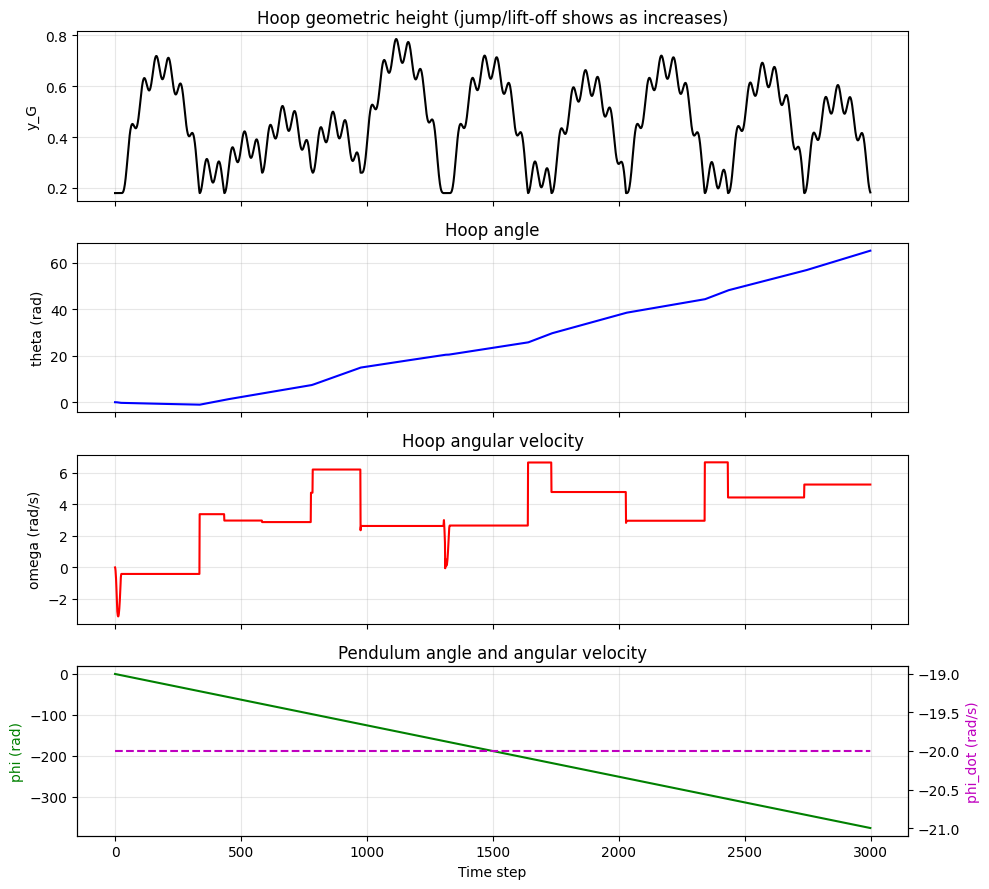

In [398]:
# Plot geometric height, angle, angular velocity, and pendulum angle
theta = q[2, :]
omega = u[2, :]
phi = q[3, :] if q.shape[0] > 3 else np.zeros_like(theta)
phi_dot = u[3, :] if u.shape[0] > 3 else np.zeros_like(omega)
yG = q[1, :]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

axes[0].plot(yG, 'k-', linewidth=1.5)
axes[0].set_ylabel('y_G')
axes[0].set_title('Hoop geometric height (jump/lift-off shows as increases)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta, 'b-', linewidth=1.5)
axes[1].set_ylabel('theta (rad)')
axes[1].set_title('Hoop angle')
axes[1].grid(True, alpha=0.3)

axes[2].plot(omega, 'r-', linewidth=1.5)
axes[2].set_ylabel('omega (rad/s)')
axes[2].set_title('Hoop angular velocity')
axes[2].grid(True, alpha=0.3)

ax3b = axes[3].twinx()
axes[3].plot(phi, 'g-', linewidth=1.5, label='phi')
ax3b.plot(phi_dot, 'm--', linewidth=1.5, label='phi_dot')
axes[3].set_ylabel('phi (rad)', color='g')
ax3b.set_ylabel('phi_dot (rad/s)', color='m')
axes[3].set_xlabel('Time step')
axes[3].set_title('Pendulum angle and angular velocity')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

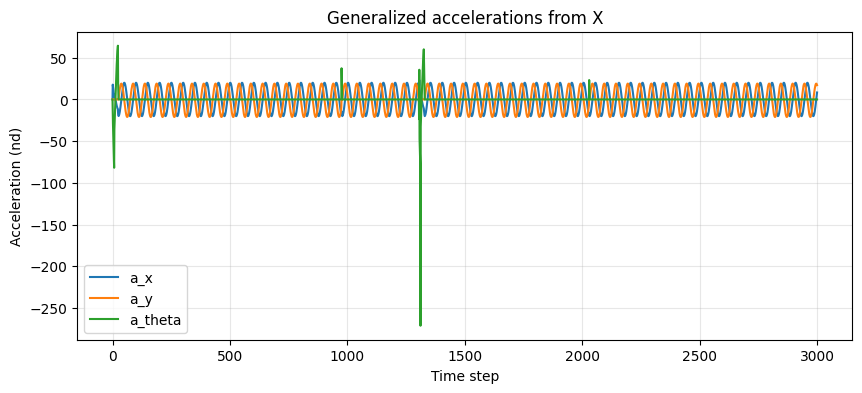

In [399]:
# Plot acceleration components from X array (a_x, a_y, a_theta) if present
if X.shape[0] >= 3:
    a_x = X[0, :]
    a_y = X[1, :]
    a_th = X[2, :]

    plt.figure(figsize=(10, 4))
    plt.plot(a_x, label='a_x')
    plt.plot(a_y, label='a_y')
    plt.plot(a_th, label='a_theta')
    plt.xlabel('Time step')
    plt.ylabel('Acceleration (nd)')
    plt.title('Generalized accelerations from X')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("X does not contain at least 3 acceleration components.")

[animation] Using output: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-03-06_21-36-20
[animation] q[:,0] = [0.2  0.18 0.   0.  ]
Saving GIF animation to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-03-06_21-36-20\hulahoop_motion_hoop_pendulum_2026-03-06_21-36-20.gif
GIF saved to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-03-06_21-36-20\hulahoop_motion_hoop_pendulum_2026-03-06_21-36-20.gif
Converting GIF to MP4: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-03-06_21-36-20\hulahoop_motion_hoop_pendulum_2026-03-06_21-36-20.mp4
MP4 saved to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-03-06_21-36-20\hulahoop_motion_hoop_pendulum_2026-03-06_21-36-20.mp4


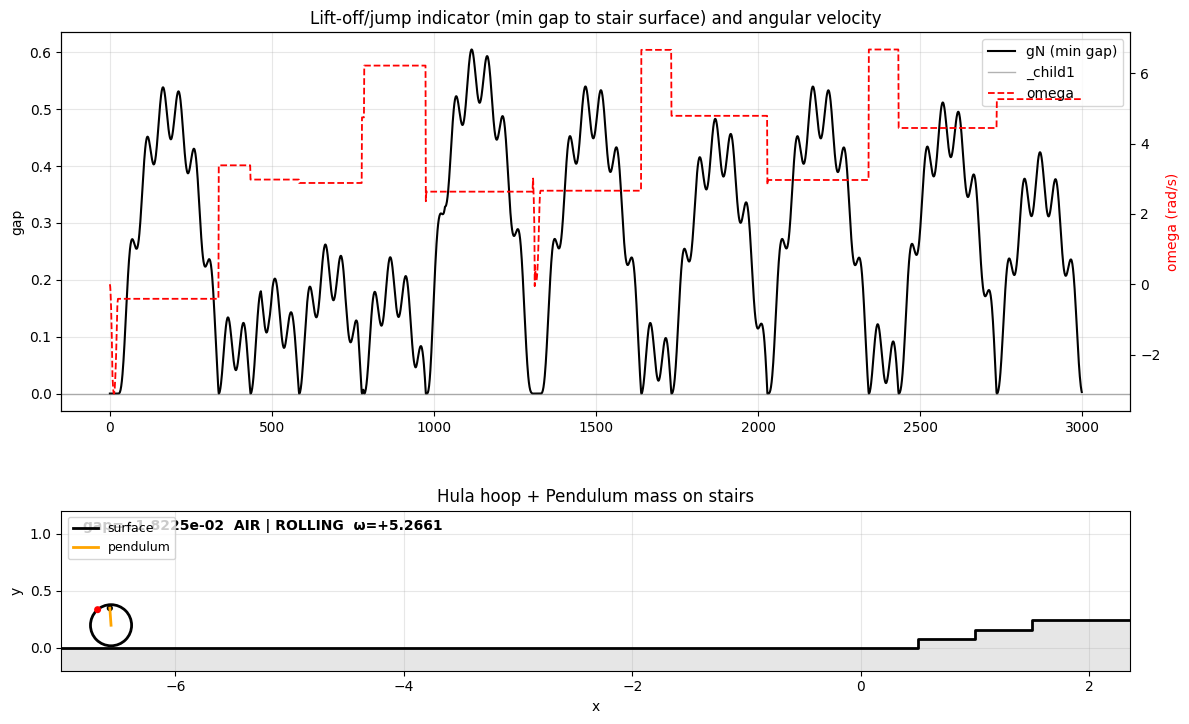

In [400]:
import matplotlib.animation as animation
from matplotlib.patches import Circle

# Defensive reload: if you changed OUTPUT_DIR, rerunning *this* cell will still pick up the new data.
q = np.load(OUTPUT_DIR / "q_save.npy")
u = np.load(OUTPUT_DIR / "u_save.npy")
X = np.load(OUTPUT_DIR / "X_save.npy")
params_path = OUTPUT_DIR / "params.json"
params = json.loads(params_path.read_text(encoding="utf-8")) if params_path.exists() else {}
print("[animation] Using output:", OUTPUT_DIR)
print("[animation] q[:,0] =", q[:, 0])

# Reload stair segments from .npy (matches simulation output)
_seg_path = OUTPUT_DIR / "stair_segments.npy"
if _seg_path.exists():
    stair_segments = np.load(_seg_path)
else:
    stair_segments = np.array([[-1e6, 0.0, 1e6, 0.0]])

# Load pendulum data if available
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    has_pendulum = True
except FileNotFoundError:
    phi = np.zeros(q.shape[1])
    has_pendulum = False
    print("[animation] No pendulum data found; visualizing as fixed")

# Parameters (prefer saved params.json)
R = float(params.get("R", 0.1))
l_pendulum = float(params.get("l_pendulum", 0.5))

xG = q[0, :]
yG = q[1, :]
theta = q[2, :]
omega = u[2, :]  # Angular velocity for rotation detection

# --- Compute minimum gap to stair surface using segment-based closest point ---
gN = np.zeros(len(xG))
for i in range(len(xG)):
    _, _, dist, _, _ = closest_point_on_segments(xG[i], yG[i], stair_segments)
    gN[i] = dist - R

# Pendulum mass position (attached at hoop center, angle phi relative to global frame)
if has_pendulum:
    xP = xG + l_pendulum * np.cos(phi)
    yP = yG + l_pendulum * np.sin(phi)
else:
    xP = xG + l_pendulum * np.cos(np.zeros_like(theta))
    yP = yG + l_pendulum * np.sin(np.zeros_like(theta))

# Point on hoop rim (initially at +x direction relative to hoop center)
xR = xG + R * np.cos(theta)
yR = yG + R * np.sin(theta)

# ---- Figure layout ----
fig = plt.figure(figsize=(12, 8))

# 1) Time histories (gap and omega)
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(gN, 'k-', lw=1.5, label='gN (min gap)')
ax1.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax1.set_ylabel('gap')
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(u[2, :], 'r--', lw=1.3, label='omega')
ax1b.set_ylabel('omega (rad/s)', color='r')
ax1.set_title('Lift-off/jump indicator (min gap to stair surface) and angular velocity')

# Combined legend
lines = ax1.get_lines() + ax1b.get_lines()
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc='upper right')

# 2) Animation
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_aspect('equal')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Hula hoop + Pendulum mass on stairs')
ax2.grid(True, alpha=0.3)

# axis limits from data
xmin = float(min(np.min(xG), np.min(xP)) - 2 * R)
xmax = float(max(np.max(xG), np.max(xP)) + 2 * R)
ymin = -0.2
ymax = float(max(np.max(yG), np.max(yP)) + 2 * R)

# Extend range to include stair edges
n_stairs_cfg = params.get("n_stairs", 0)
stair_x_start_cfg = params.get("stair_x_start", 0)
stair_width_cfg = params.get("stair_width", 0)
stair_height_cfg = params.get("stair_height", 0)
if n_stairs_cfg > 0:
    x_last = stair_x_start_cfg + n_stairs_cfg * stair_width_cfg
    h_top = n_stairs_cfg * stair_height_cfg
    xmin = min(xmin, stair_x_start_cfg - 2 * R)
    xmax = max(xmax, x_last + 2 * R)
    ymax = max(ymax, h_top + 2 * R)

ax2.set_xlim(xmin, xmax)
ax2.set_ylim(ymin, ymax)

# Draw stair surface from segments
stair_xs, stair_ys = build_stair_polyline_from_segments(
    stair_segments, x_pad_left=abs(xmin) + 1, x_pad_right=abs(xmax) + 1
)
ax2.plot(stair_xs, stair_ys, 'k-', lw=2, label='surface')

# Optional shading below stair surface
ax2.fill_between(stair_xs, stair_ys, ymin, color='0.90', zorder=0)

# Hoop circle (centered at G)
hoop_circle = Circle((xG[0], yG[0]), R, fill=False, edgecolor='black', linewidth=2)
ax2.add_patch(hoop_circle)

# Colored point on hoop rim (initially blue - stationary)
rim_point = Circle((xR[0], yR[0]), 0.12 * R if R > 0 else 0.02, color='blue', ec='black', lw=1.5)
ax2.add_patch(rim_point)

# Pendulum mass marker
pend_patch = Circle((xP[0], yP[0]), 0.1 * R if R > 0 else 0.015, color='orange', ec='black', lw=1.5)
ax2.add_patch(pend_patch)

# Pendulum line from G to pendulum mass
pend_line, = ax2.plot([xG[0], xP[0]], [yG[0], yP[0]], 'orange', lw=2, label='pendulum')

# Text showing lift-off and rotation status
status_text = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, va='top', fontsize=10, fontweight='bold')

# Legend for markers
ax2.legend(loc='upper left', fontsize=9)

# Threshold for rotation detection
rotation_threshold = 0.01

def init():
    hoop_circle.center = (xG[0], yG[0])
    rim_point.center = (xR[0], yR[0])
    pend_patch.center = (xP[0], yP[0])
    pend_line.set_data([xG[0], xP[0]], [yG[0], yP[0]])
    status_text.set_text('')
    return hoop_circle, rim_point, pend_patch, pend_line, status_text

def animate(i):
    hoop_circle.center = (xG[i], yG[i])
    rim_point.center = (xR[i], yR[i])
    pend_patch.center = (xP[i], yP[i])
    pend_line.set_data([xG[i], xP[i]], [yG[i], yP[i]])
    
    # Change rim point color based on rotation: red if rotating, blue if stationary
    if abs(omega[i]) > rotation_threshold:
        rim_point.set_color('red')
        rotation_status = "ROLLING"
    else:
        rim_point.set_color('blue')
        rotation_status = "SLIDING"
    
    contact_status = 'AIR' if gN[i] > 1e-6 else 'CONTACT'
    status_text.set_text(f"gap={gN[i]:+.4e}  {contact_status} | {rotation_status}  ω={omega[i]:+.4f}")
    return hoop_circle, rim_point, pend_patch, pend_line, status_text

step = 5
frames = range(0, q.shape[1], step)
anim = animation.FuncAnimation(fig, animate, init_func=init, frames=frames, interval=20, blit=True)

# Step 1: Save as GIF using PillowWriter (no system dependencies)
gif_path = OUTPUT_DIR / f"hulahoop_motion_{OUTPUT_DIR.name}.gif"
print("Saving GIF animation to:", gif_path)
anim.save(gif_path.as_posix(), writer=animation.PillowWriter(fps=30))
print("GIF saved to:", gif_path)

# Step 2: Convert GIF to MP4 using imageio (bundles its own ffmpeg)
# Use get_reader() to stream frames one-by-one instead of mimread() which loads all into RAM
import imageio
mp4_path = OUTPUT_DIR / f"hulahoop_motion_{OUTPUT_DIR.name}.mp4"
print("Converting GIF to MP4:", mp4_path)
reader = imageio.get_reader(gif_path.as_posix())
mp4_writer = imageio.get_writer(mp4_path.as_posix(), fps=30, codec='libx264', quality=8)
for frame in reader:
    # Convert RGBA to RGB if needed
    if frame.shape[-1] == 4:
        frame = frame[:, :, :3]
    mp4_writer.append_data(frame)
reader.close()
mp4_writer.close()
print("MP4 saved to:", mp4_path)

plt.tight_layout()
plt.show()

In [401]:
np.set_printoptions(precision=17, suppress=False)
print("Min gap (gN) over time:")
print(gN[:50])
print("\nHoop position x over time:")
print(q[0, :50])
print("\nHoop angle (theta) over time:")
print(q[2, :50])
if has_pendulum_data:
    print("\nPendulum angle (phi) over time:")
    print(phi[:50])
    print("\nPendulum angular velocity (phi_dot):")
    print(phi_dot[:50])
print(f"\nStair config: n_stairs={params.get('n_stairs', 0)}, "
      f"width={params.get('stair_width', 0)}, height={params.get('stair_height', 0)}, "
      f"x_start={params.get('stair_x_start', 0)}")
print(f"Number of stair segments: {len(stair_segments)}")

Min gap (gN) over time:
[ 0.0000000000000000e+00  5.5511151231257827e-17 -2.7755575615628914e-17
  0.0000000000000000e+00  0.0000000000000000e+00 -2.7755575615628914e-17
  5.5511151231257827e-17 -1.6653345369377348e-16  0.0000000000000000e+00
 -2.7755575615628914e-17  0.0000000000000000e+00 -2.7755575615628914e-17
  0.0000000000000000e+00 -2.7755575615628914e-17 -2.7755575615628914e-17
  2.7755575615628914e-17 -2.7755575615628914e-17  0.0000000000000000e+00
  0.0000000000000000e+00  2.7755575615628914e-17 -2.8310687127941492e-15
  5.5511151231257827e-17  6.3454796972450822e-13 -1.3206102877916237e-13
  2.7755575615628914e-17 -5.5511151231257827e-17  2.2521675359099547e-06
  5.6400066211298450e-05  2.5868030626008398e-04  7.0239013300049669e-04
  1.4764244179245878e-03  2.6638811102834559e-03  4.3407577319685142e-03
  6.5747592863222015e-03  9.4242362427434112e-03  1.2937269255729050e-02
  1.7150914975484322e-02  2.2090624780225804e-02  2.7769845547834043e-02
  3.4189808729153531e-02  4

gNdot shape: (1, 3000) (1 contact(s))
gNddot shape: (1, 3000)
lambdaN shape: (1, 3000)
lambdaF shape: (1, 3000)


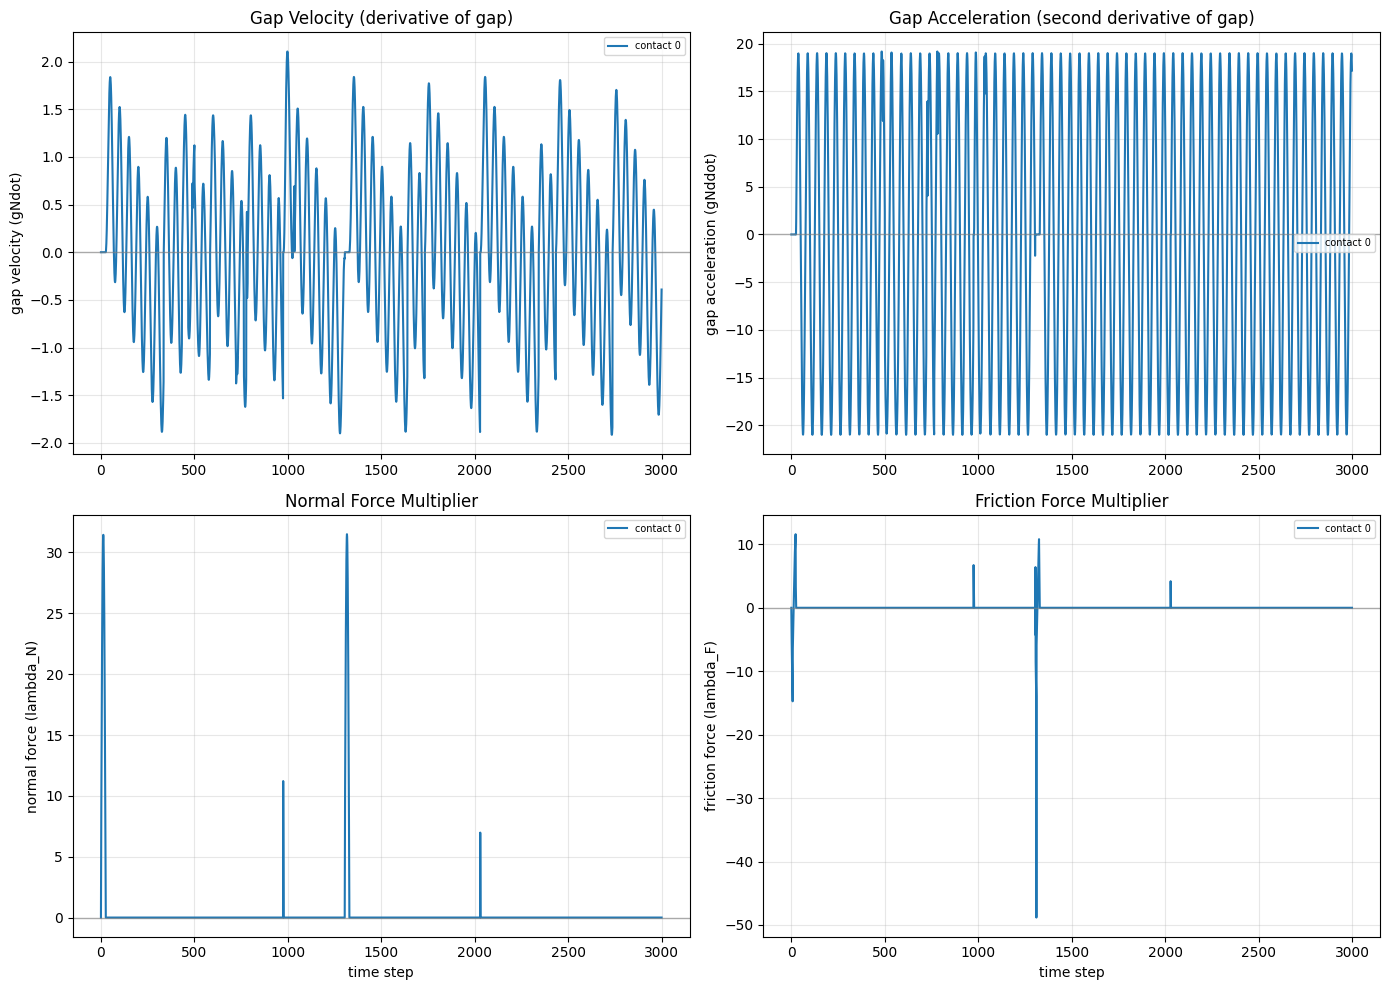

In [402]:
# Load and plot gNdot, gNddot, lambda_F, lambda_N (supports multiple contacts)
gNdot = np.load(OUTPUT_DIR / "gNdot_save.npy")
gNddot = np.load(OUTPUT_DIR / "gNddot_save.npy")
lambdaN = np.load(OUTPUT_DIR / "lambdaN_save.npy")

# Try loading lambdaF_save.npy first, fall back to gammaF_save.npy for older simulations
try:
    lambdaF = np.load(OUTPUT_DIR / "lambdaF_save.npy")
except FileNotFoundError:
    lambdaF = np.load(OUTPUT_DIR / "gammaF_save.npy")

nN = gNdot.shape[0]
nF = lambdaF.shape[0]
print("gNdot shape:", gNdot.shape, f"({nN} contact(s))")
print("gNddot shape:", gNddot.shape)
print("lambdaN shape:", lambdaN.shape)
print("lambdaF shape:", lambdaF.shape)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Create figure with subplots
fig_forces = plt.figure(figsize=(14, 10))

# 1) gNdot (velocity of gap)
ax1 = fig_forces.add_subplot(2, 2, 1)
for i in range(nN):
    lbl = f"contact {i}"
    ax1.plot(gNdot[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax1.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax1.set_ylabel('gap velocity (gNdot)')
ax1.set_title('Gap Velocity (derivative of gap)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=7)

# 2) gNddot (acceleration of gap)
ax2 = fig_forces.add_subplot(2, 2, 2)
for i in range(nN):
    lbl = f"contact {i}"
    ax2.plot(gNddot[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax2.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax2.set_ylabel('gap acceleration (gNddot)')
ax2.set_title('Gap Acceleration (second derivative of gap)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=7)

# 3) lambda_N (normal force)
ax3 = fig_forces.add_subplot(2, 2, 3)
for i in range(nN):
    lbl = f"contact {i}"
    ax3.plot(lambdaN[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax3.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax3.set_xlabel('time step')
ax3.set_ylabel('normal force (lambda_N)')
ax3.set_title('Normal Force Multiplier')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=7)

# 4) lambda_F (friction force)
ax4 = fig_forces.add_subplot(2, 2, 4)
for i in range(nF):
    lbl = f"contact {i}"
    ax4.plot(lambdaF[i, :], color=colors[i % len(colors)], lw=1.5, label=lbl)
ax4.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax4.set_xlabel('time step')
ax4.set_ylabel('friction force (lambda_F)')
ax4.set_title('Friction Force Multiplier')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=7)

plt.tight_layout()
plt.show()

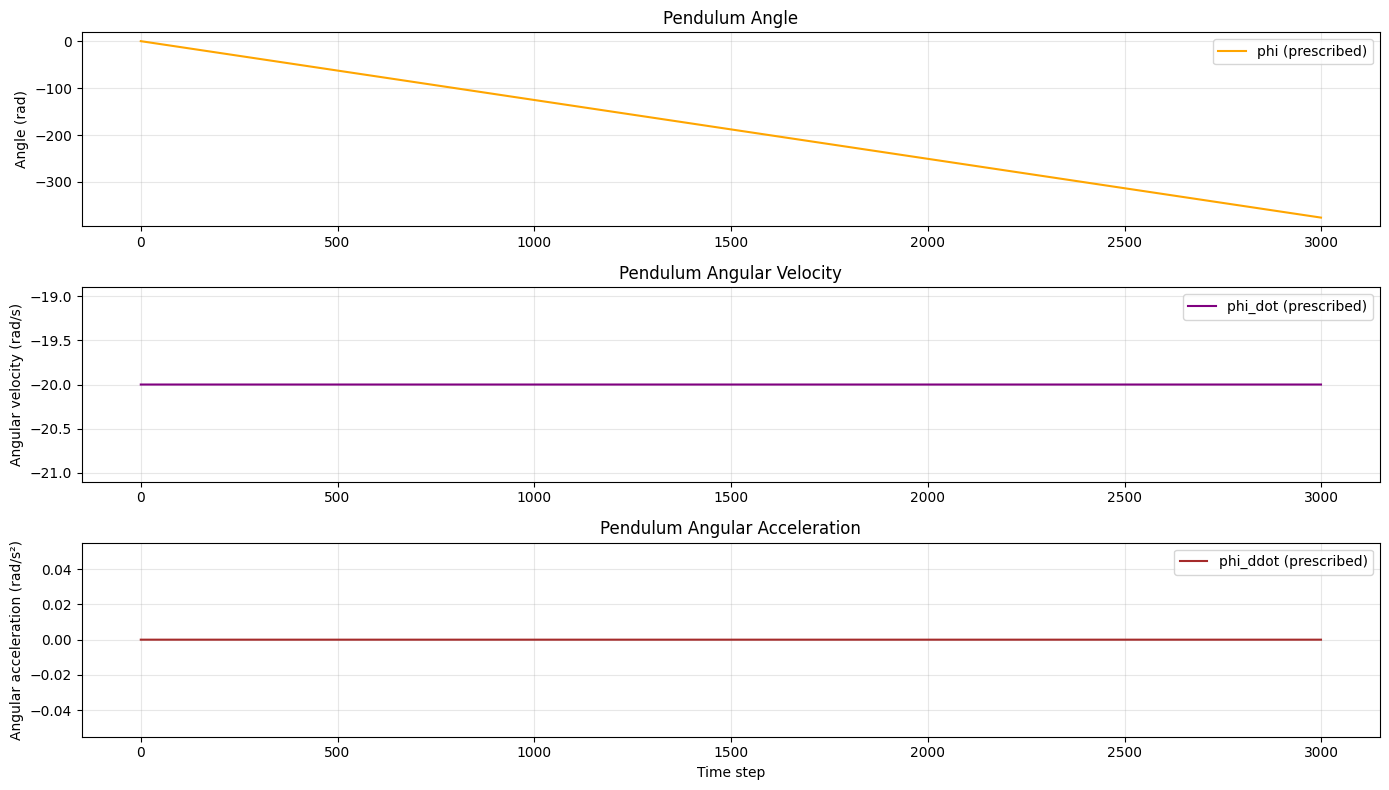

In [403]:
# Load and plot pendulum data
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    phi_dot = np.load(OUTPUT_DIR / "phi_dot_save.npy")
    phi_ddot = np.load(OUTPUT_DIR / "phi_ddot_save.npy")
    
    fig_pend = plt.figure(figsize=(14, 8))
    
    # 1) Pendulum angle
    ax1 = fig_pend.add_subplot(3, 1, 1)
    ax1.plot(phi, 'orange', lw=1.5, label='phi (prescribed)')
    ax1.set_ylabel('Angle (rad)')
    ax1.set_title('Pendulum Angle')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2) Pendulum angular velocity
    ax2 = fig_pend.add_subplot(3, 1, 2)
    ax2.plot(phi_dot, 'purple', lw=1.5, label='phi_dot (prescribed)')
    ax2.set_ylabel('Angular velocity (rad/s)')
    ax2.set_title('Pendulum Angular Velocity')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3) Pendulum angular acceleration
    ax3 = fig_pend.add_subplot(3, 1, 3)
    ax3.plot(phi_ddot, 'brown', lw=1.5, label='phi_ddot (prescribed)')
    ax3.set_ylabel('Angular acceleration (rad/s²)')
    ax3.set_xlabel('Time step')
    ax3.set_title('Pendulum Angular Acceleration')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError as e:
    print(f"Pendulum data not found: {e}")


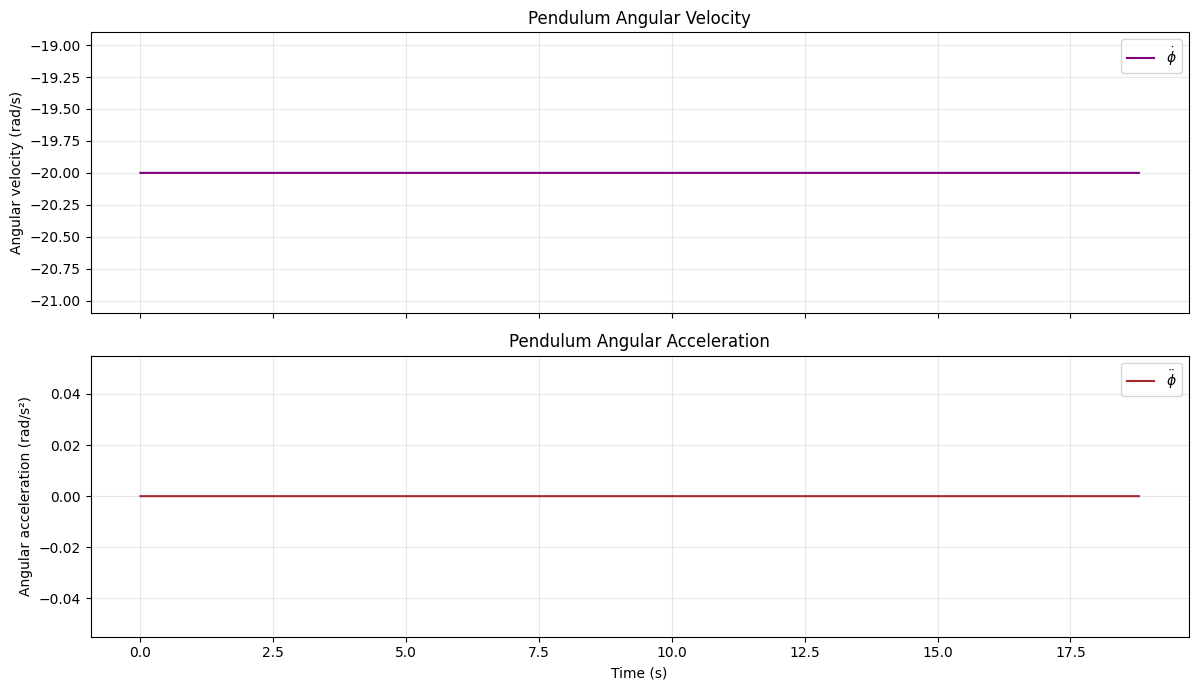

In [404]:
# Pendulum angular velocity & angular acceleration
if has_pendulum_data:
    dtime = params.get("dtime", 1.0)
    t = np.arange(len(phi_dot)) * dtime

    fig_pend_va, (ax_omega_p, ax_alpha_p) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # --- Angular velocity (phi_dot) ---
    ax_omega_p.plot(t, phi_dot, color='purple', lw=1.5, label=r'$\dot{\phi}$')
    ax_omega_p.set_ylabel('Angular velocity (rad/s)')
    ax_omega_p.set_title('Pendulum Angular Velocity')
    ax_omega_p.legend()
    ax_omega_p.grid(True, alpha=0.3)

    # --- Angular acceleration (phi_ddot) ---
    ax_alpha_p.plot(t, phi_ddot, color='brown', lw=1.5, label=r'$\ddot{\phi}$')
    ax_alpha_p.set_ylabel('Angular acceleration (rad/s²)')
    ax_alpha_p.set_xlabel('Time (s)')
    ax_alpha_p.set_title('Pendulum Angular Acceleration')
    ax_alpha_p.legend()
    ax_alpha_p.grid(True, alpha=0.3)

    fig_pend_va.tight_layout()
    plt.show()
else:
    print("No pendulum data available — skipping phi_dot / phi_ddot plots.")

In [405]:
print("phi", phi[:50])

phi [ 0.                 -0.1253254532580126 -0.2506509065160252
 -0.3759763597740378 -0.5013018130320503 -0.6266272662900629
 -0.7519527195480756 -0.8772781728060883 -1.0026036260641007
 -1.1279290793221133 -1.2532545325801259 -1.3785799858381387
 -1.5039054390961513 -1.6292308923541636 -1.7545563456121767
 -1.879881798870189  -2.0052072521282014 -2.130532705386214
 -2.2558581586442266 -2.3811836119022396 -2.5065090651602517
 -2.6318345184182643 -2.757159971676278  -2.8824854249342895
 -3.0078108781923025 -3.133136331450315  -3.2584617847083273
 -3.3837872379663403 -3.5091126912243533 -3.6344381444823655
 -3.759763597740378  -3.88508905099839   -4.010414504256403
 -4.135739957514416  -4.261065410772428  -4.386390864030441
 -4.511716317288453  -4.637041770546466  -4.762367223804479
 -4.887692677062491  -5.0130181303205035 -5.138343583578516
 -5.263669036836529  -5.388994490094542  -5.514319943352555
 -5.639645396610567  -5.764970849868579  -5.890296303126592
 -6.015621756384605  -6.140